## Lab 2: Predictive Analytics with Machine Learning

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"



### Section 1 - Supervised Learning: Regression

Part 1.1 — Load and explore the taxi data

<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB
(41202, 13) 
 None 
        VendorID  passenger_count  trip_distance    

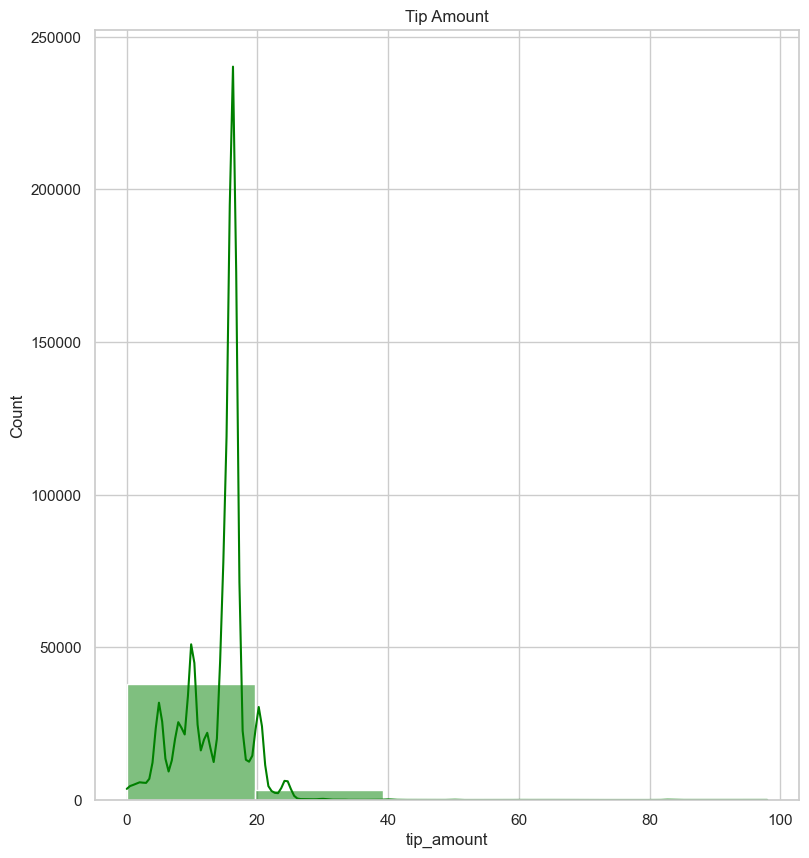

In [3]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)
taxi = pd.read_csv(TAXI_URL)


# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()
x = taxi.shape
y = taxi.info()
z = taxi.describe()
a = taxi.isna().sum()
print(x,'\n', y,'\n', z,'\n', a)

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
Taxi_Display = pd.DataFrame(taxi)

plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
sns.histplot(Taxi_Display['tip_amount'], kde=True, bins=5, color='green')
plt.title('Tip Amount')
plt.show()

Part 1.2 — Preprocessing & feature engineering

In [4]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
#cleaning the data
taxi = taxi[(taxi['trip_distance'] > 0) & (taxi['fare_amount'] > 0 )]
taxi = taxi.dropna()

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
#feature engineering
taxi['fare_per_mile'] = taxi['fare_amount']/taxi['trip_distance'] #feature 1

taxi['total_surcharges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge'] #feature 2

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
catCols = [
    'VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag'
]

if all(col in taxi.columns for col in catCols):
    for col in catCols:
        taxi[col] = taxi[col].astype(str)
    taxi = pd.get_dummies(taxi, columns=catCols, drop_first=True, dtype=int)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
dropCols = taxi.drop(columns=[
    'tip_amount', 'PULocationID', 'DOLocationID'
])

y = taxi['tip_amount']




from sklearn.model_selection import train_test_split

dropCols_train, dropCols_test, y_train, y_test = train_test_split(
    dropCols, y, test_size=0.2, random_state=RANDOM_STATE
    )

for col in dropCols:
    dropCols_train[col] = dropCols_train[col].astype(float)
    dropCols_test[col] = dropCols_test[col].astype(float)


numCols = [
    'passenger_count', 'trip_distance', 'fare_amount', 'mta_tax', 
    'tolls_amount', 'improvement_surcharge', 'fare_per_mile', 'total_surcharges'
]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

dropCols_train[numCols] = scaler.fit_transform(dropCols_train[numCols])
dropCols_test[numCols] = scaler.fit_transform(dropCols_test[numCols])

Part 1.3 — Train / Validation / Test split

In [5]:
# Seperate features (X) and target (y = tip_amount)
X = taxi.drop(columns=['tip_amount', 'PULocationID', 'DOLocationID'])
y = taxi['tip_amount']

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
from sklearn.model_selection import train_test_split

# Split off the test set (20% of total data)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Split the remainder into train (60% of total data) and validation (20% of total data)
# Since X_train_val contains 80% of total data, test_size=0.25 yields 20% validation set (0.25 * 0.8 = 0.2)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE
)

Part 1.4 — Train a regressor and check for overfitting

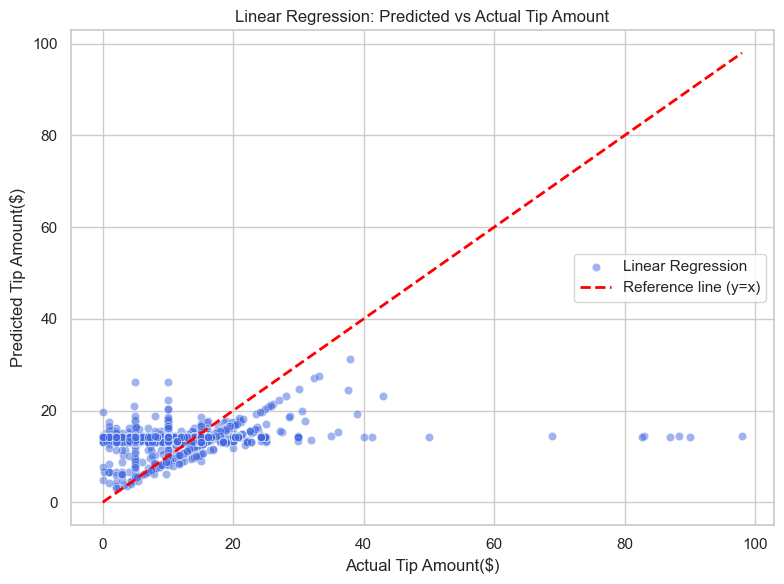

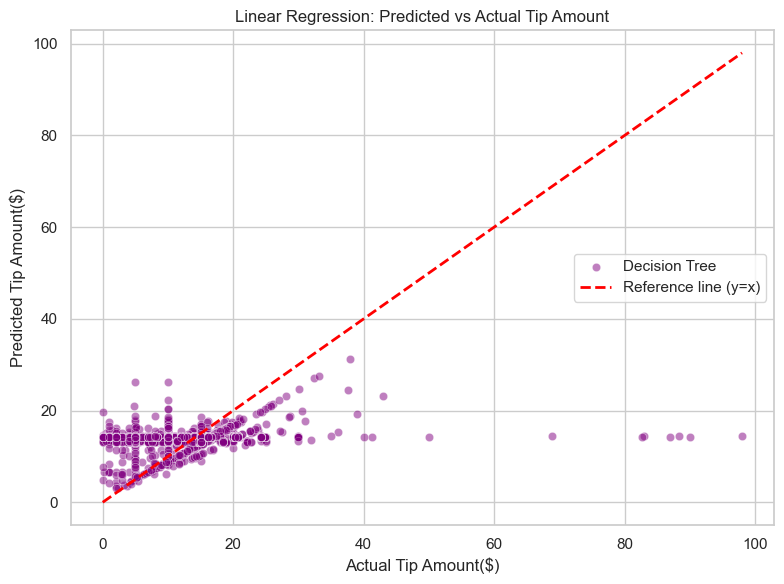

In [6]:
# Import, initialise, and train a regression model.
# Start simple (LinearRegression), then try a more flexible model
# (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lrModel = LinearRegression() #initialise
lrModel.fit(X_train, y_train) #train

#Decision Tree model
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

dtModel = DecisionTreeRegressor(max_depth = 10, random_state = RANDOM_STATE) #initialise
dtModel.fit(X_train, y_train)


# TODO: Predict on train, validation, and test sets.

#Linear Regression
y_pred_trainLR = lrModel.predict(X_train)
y_pred_valLR = lrModel.predict(X_val)
y_pred_testLR = lrModel.predict(X_test)

#Decision Tree
y_pred_trainDT = dtModel.predict(X_train)
y_pred_valDT = dtModel.predict(X_val)
y_pred_testDT = dtModel.predict(X_test)


# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

#Linear Regression
LR_rmse_train = np.sqrt(
    mean_squared_error(y_train, y_pred_trainLR)
)
LR_rmse_val = np.sqrt(
    mean_squared_error(y_val, y_pred_valLR)
)
LR_rmse_test = np.sqrt(
    mean_squared_error(y_test, y_pred_testLR)
)

LR_r2_train = r2_score(y_train, y_pred_trainLR)
LR_r2_val = r2_score(y_val, y_pred_valLR)
LR_r2_test = r2_score(y_test, y_pred_testLR)

#Decision Tree
DT_rmse_train = np.sqrt(
    mean_squared_error(y_train, y_pred_trainDT)
)
DT_rmse_val = np.sqrt(
    mean_squared_error(y_val, y_pred_valDT)
)
DT_rmse_test = np.sqrt(
    mean_squared_error(y_test, y_pred_testDT)
)

LR_r2_train = r2_score(y_train, y_pred_trainLR)
LR_r2_val = r2_score(y_val, y_pred_valLR)
LR_r2_test = r2_score(y_test, y_pred_testLR)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).

#Linear Regression
#Plot Style
sns.set_theme(style = "whitegrid")
plt.figure(figsize = (8,6))

#Actual Plot vs LR Predictions
sns.scatterplot(
    x = y_test, y = y_pred_testLR, alpha = 0.5, color = 'royalblue', label = 'Linear Regression'
)

#limits
min_valLR = min(y_test.min(), y_pred_testLR.min())
max_valLR = max(y_test.max(), y_pred_testLR.max())

#y=x reference line plot
plt.plot(
    [min_valLR, max_valLR], [min_valLR, max_valLR], color='red', 
    linestyle = '--', linewidth = 2, label = 'Reference line (y=x)'
)

#labels and formatting
plt.xlabel('Actual Tip Amount($)')
plt.ylabel('Predicted Tip Amount($)')
plt.title('Linear Regression: Predicted vs Actual Tip Amount')
plt.legend(loc = 'right')
plt.tight_layout()
plt.show()

#Decision Tree
#Plot Style
sns.set_theme(style = "whitegrid")
plt.figure(figsize = (8,6))

#Actual Plot vs LR Predictions
sns.scatterplot(
    x = y_test, y = y_pred_testLR, alpha = 0.5, color = 'purple', label = 'Decision Tree'
)

#limits
min_valDT = min(y_test.min(), y_pred_testDT.min())
max_valDT = max(y_test.max(), y_pred_testDT.max())

#y=x reference line plot
plt.plot(
    [min_valDT, max_valDT], [min_valDT, max_valDT], color='red', 
    linestyle = '--', linewidth = 2, label = 'Reference line (y=x)'
)

#labels and formatting
plt.xlabel('Actual Tip Amount($)')
plt.ylabel('Predicted Tip Amount($)')
plt.title('Linear Regression: Predicted vs Actual Tip Amount')
plt.legend(loc = 'right')
plt.tight_layout()
plt.show()


### Section 2: Supervised Learning: Multi-class Classification
Part 2.1 — Load and explore the obesity data

Shape: (2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Tran

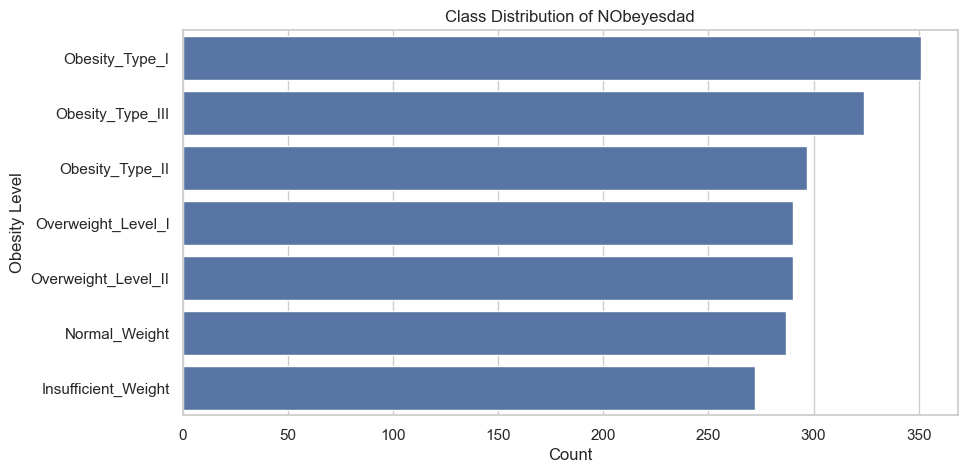

In [7]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print("Shape:", obesity.shape)
print(obesity.head())
obesity.info()
print(obesity.describe(include="all"))
print("Missing values:\n", obesity.isnull().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
print("\nClass distribution:")
print(obesity["NObeyesdad"].value_counts())
plt.figure(figsize=(10, 5))
sns.countplot(data=obesity, y="NObeyesdad", order=obesity["NObeyesdad"].value_counts().index)
plt.title("Class Distribution of NObeyesdad")
plt.xlabel("Count")
plt.ylabel("Obesity Level")
plt.show()

Part 2.2 — Preprocessing & feature engineering

In [8]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
obesityEncode = obesity.copy()

#binary encoding
binaryCols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binaryCols:
    obesityEncode[col] = obesityEncode[col].map({"yes": 1, "no": 0})

#gender enconding
obesityEncode["Gender"] = obesityEncode["Gender"].map(
    {"Female": 0, "Male": 1}
)

#Frequency encoding
freqCols = ["CAEC", "CALC"]
freqMapping = {
    "no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3 
}
for col in  freqCols:
    obesityEncode[col] = obesityEncode[col].map(freqMapping)

#One-Hot encoding (MTRANS)
obesityEncode = pd.get_dummies(
    obesityEncode, columns = ["MTRANS"], drop_first = True, dtype = int
)

obesityEncode.head()


# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

#BMI feature domain
obesityEncode["BMI"] = obesityEncode["Weight"]/(obesityEncode["Height"]**2)




# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
obesityEncode["NObeyesdad_label"] = le.fit_transform(obesityEncode["NObeyesdad"])

obesityEncode.head()

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = obesityEncode.drop(columns = ["NObeyesdad", "NObeyesdad_label"])
y = obesityEncode["NObeyesdad_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Part 2.3 — Stratified Train / Validation / Test split

In [9]:
# TODO: Separate X (features) and y (encoded NObeyesdad).

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.

# TODO: Fit the scaler on the training set only, then transform train / val / test.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = obesityEncode.drop(columns=["NObeyesdad", "NObeyesdad_label"])
y = obesityEncode["NObeyesdad_label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Part 2.4 — Train a classifier and check for overfitting

Logistic Regression Performance
Train Set - Accuracy: 0.9282 Macro-F1: 0.9258
Val Set   - Accuracy: 0.9085  Macro-F1: 0.9068
Test Set  - Accuracy: 0.8738 Macro-F1: 0.8696



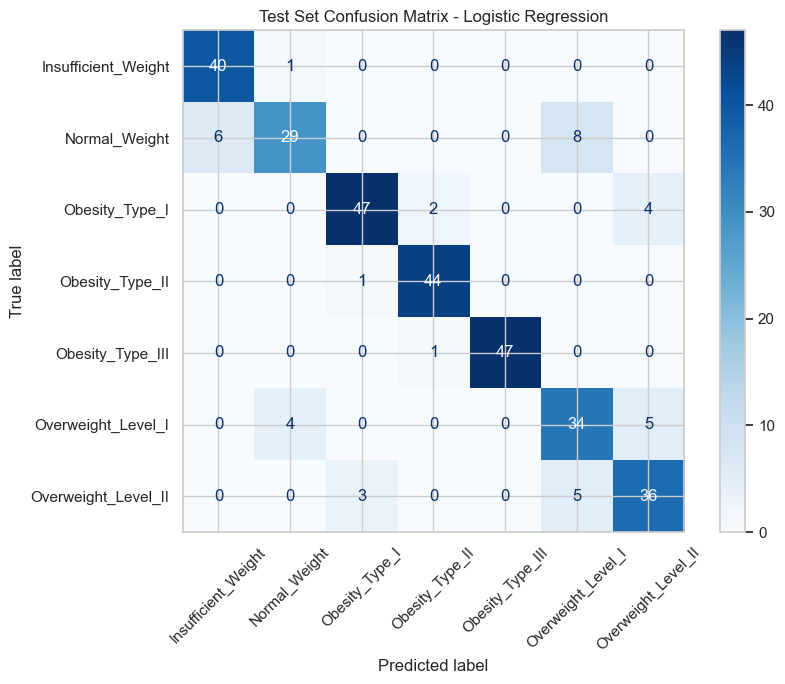

In [10]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

lrModel = LogisticRegression(max_iter= 1000, random_state = RANDOM_STATE) #initialise
lrModel.fit(X_train_scaled, y_train) #train

# TODO: Predict on train, validation, and test.
y_train_pred = lrModel.predict(X_train_scaled)
y_val_pred   = lrModel.predict(X_val_scaled)
y_test_pred  = lrModel.predict(X_test_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Logistic Regression Performance")
print(f"Train Set - Accuracy: {accuracy_score(y_train, y_train_pred):.4f}", 
    f"Macro-F1: {f1_score(y_train, y_train_pred, average='macro'):.4f}")
print(f"Val Set   - Accuracy: {accuracy_score(y_val, y_val_pred):.4f} ",
    f"Macro-F1: {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"Test Set  - Accuracy: {accuracy_score(y_test, y_test_pred):.4f}",
    f"Macro-F1: {f1_score(y_test, y_test_pred, average='macro'):.4f}\n")

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, 
    display_labels=le.classes_, 
    xticks_rotation=45, 
    cmap="Blues", 
    ax=ax
)
plt.title("Test Set Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

### Section 3 — Unsupervised Learning: K-Means Clustering


Part 3.1 — Choose k, fit K-Means, and visualise

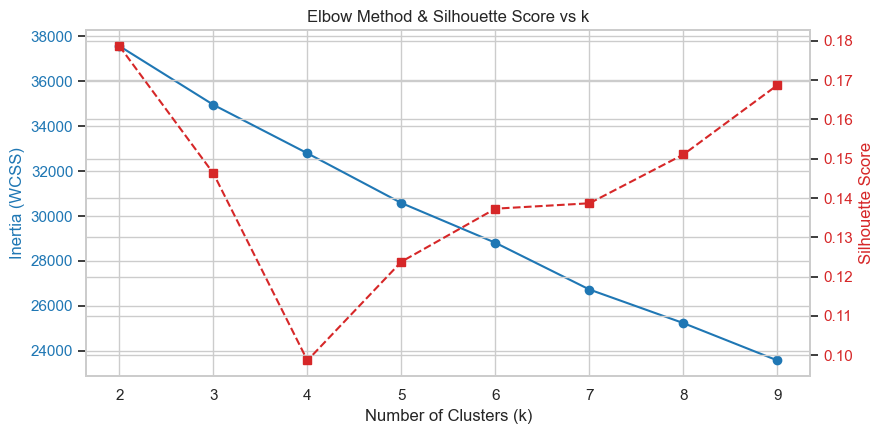

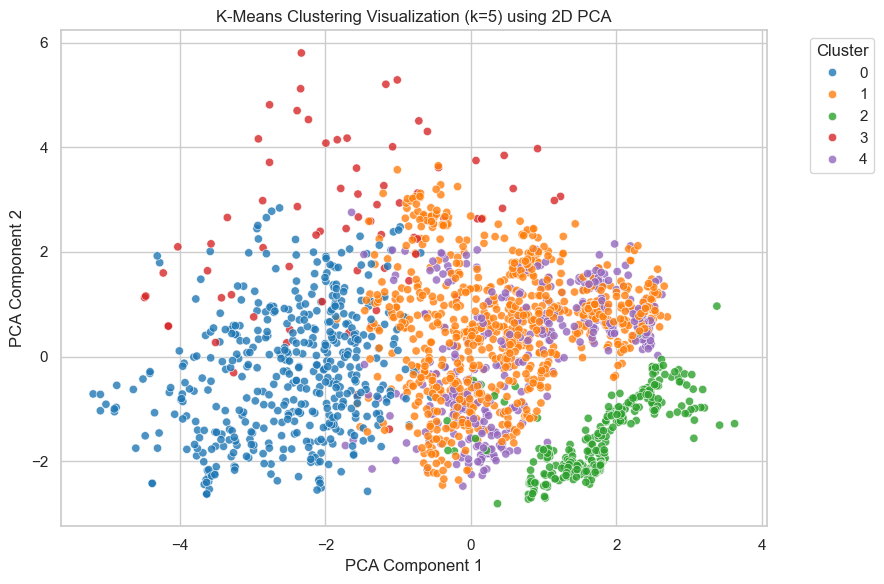

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

 # TODO: Use ONLY the scaled obesity features (no target) for clustering.
featuresX = obesityEncode.drop(columns=["NObeyesdad", "NObeyesdad_label"])
scalerAll = StandardScaler()
scaledX = scalerAll.fit_transform(featuresX)

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
inertias = []
silhouettes = []
kRange = range(2,10)

for k in kRange:
    kmeans = KMeans(
        n_clusters=k, random_state=RANDOM_STATE, n_init=10
    )
    kmeans.fit(scaledX)

    inertias.append(kmeans.inertia_)
    silhouettes.append(
        silhouette_score(scaledX, kmeans.labels_)
    )

#inertia and silhoutes plot
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (WCSS)", color="tab:blue")
ax1.plot(kRange, inertias, marker="o", color="tab:blue", label="Inertia")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
ax2.set_ylabel("Silhouette Score", color="tab:red")
ax2.plot(kRange, silhouettes, marker="s", color="tab:red", linestyle="--", label="Silhouette Score")
ax2.tick_params(axis="y", labelcolor="tab:red")
plt.title("Elbow Method & Silhouette Score vs k")
plt.tight_layout()
plt.show()

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
kChosen = 5
kmeansFinal = KMeans(
    n_clusters=kChosen, random_state=RANDOM_STATE, n_init=10
)
clusterLabels = kmeansFinal.fit_predict(scaledX)


# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaledX)
plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusterLabels, palette="tab10", alpha=0.8)
plt.title(f"K-Means Clustering Visualization (k={kChosen}) using 2D PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



In [14]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?

clusterCrosstab = pd.crosstab(
    clusterLabels, obesity["NObeyesdad"],
    rownames = ["Cluster"], colnames = ["Obesity Level"]
)

print(clusterCrosstab)

Obesity Level  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
Cluster                                                             
0                              192            167               4   
1                               73             59             225   
2                                0              0               6   
3                                6             42               5   
4                                1             19             111   

Obesity Level  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
Cluster                                                                
0                            1                 0                  52   
1                          196                 0                 167   
2                            2               324                   2   
3                            1                 0                  12   
4                           97                 0                  57   

Obesity Lev